In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import *

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

Mounted at /content/drive


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor

def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0

    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정

        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.

    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()

def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정

    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산

    return eval_loss, pred

def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### 1. Simple CNN
- input(1x28x28) > CNN layer(feature=32, kernel_size=3, stride=1, padding=1) > MaxPooling(2x2) > Flatten > fc1(64) > fc2(10)

In [4]:
# 데이터 준비
from torchvision import datasets
from torchvision.transforms import ToTensor

train_set = datasets.MNIST(root='data', train=True, download=True, transform = ToTensor())
test_set = datasets.MNIST(root='data', train=False, download=True, transform = ToTensor())

batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size)

x_val, x_test = test_set.data[:5000], test_set.data[5000:]
y_val, y_test = test_set.targets[:5000], test_set.targets[5000:]

x_val = x_val/255
x_test = x_test/255

# 이미지 처리를 위한 차원일치
x_val = x_val.view(5000, 1, 28, 28)
x_test = x_test.view(5000, 1, 28, 28)

In [5]:
# modeling
n_class = 10
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(32*14*14, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [6]:
# run
epochs = 10
tr_loss_list, val_loss_list = [],[]

for i in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(x_val, y_val, model, loss_fn, device)
  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"Epoch {i+1}. train loss: {tr_loss:.4f}, val loss: {val_loss:.4f}")

Epoch 1. train loss: 0.2609, val loss: 0.1340
Epoch 2. train loss: 0.0831, val loss: 0.0855
Epoch 3. train loss: 0.0555, val loss: 0.0711
Epoch 4. train loss: 0.0420, val loss: 0.0685
Epoch 5. train loss: 0.0319, val loss: 0.0698
Epoch 6. train loss: 0.0244, val loss: 0.0702
Epoch 7. train loss: 0.0181, val loss: 0.0760
Epoch 8. train loss: 0.0134, val loss: 0.0835
Epoch 9. train loss: 0.0106, val loss: 0.0951
Epoch 10. train loss: 0.0089, val loss: 0.1269


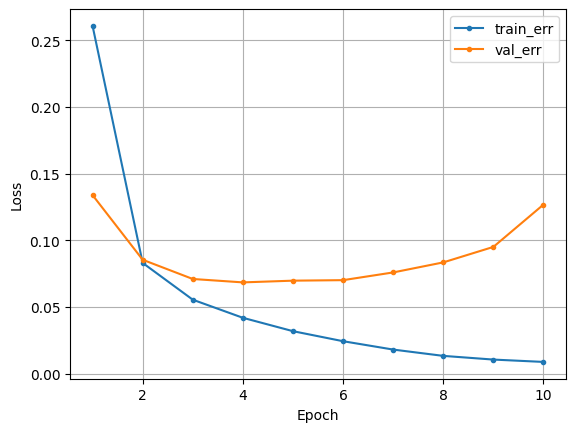

In [7]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [8]:
# predict and eval
_, pred = evaluate(x_test, y_test, model, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis=1)

print(classification_report(y_test.numpy(), pred, digits=4))

              precision    recall  f1-score   support

           0     0.9866    0.9904    0.9885       520
           1     0.9843    1.0000    0.9921       564
           2     0.9765    0.9920    0.9842       502
           3     1.0000    0.9627    0.9810       510
           4     0.9737    0.9979    0.9857       482
           5     0.9796    0.9931    0.9863       436
           6     0.9919    0.9839    0.9879       496
           7     0.9921    0.9690    0.9804       516
           8     0.9937    0.9732    0.9833       485
           9     0.9718    0.9877    0.9797       489

    accuracy                         0.9850      5000
   macro avg     0.9850    0.9850    0.9849      5000
weighted avg     0.9852    0.9850    0.9850      5000



#### 2. Multi layers CNN
- input(1x28x28) > conv1(32, 3x3) > MaxPooling(2x2) > conv2(64, 3x3) > MaxPooling(2x2) > Flatten > fc1(128) > fc2(10)

In [14]:
# model class
class CNN_model(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(64*7*7, 128)
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.flatten(x)
    x = self.relu(self.fc1(x))
    x = self.fc2(x)
    return x

In [15]:
model2 = CNN_model().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)

Epoch 1, train loss : 0.1894, val loss : 0.1103
Epoch 2, train loss : 0.0524, val loss : 0.0598
Epoch 3, train loss : 0.0340, val loss : 0.0563
Epoch 4, train loss : 0.0237, val loss : 0.0584
Epoch 5, train loss : 0.0174, val loss : 0.0809
Epoch 6, train loss : 0.0150, val loss : 0.0579
Epoch 7, train loss : 0.0124, val loss : 0.0625
Epoch 8, train loss : 0.0102, val loss : 0.0690
Epoch 9, train loss : 0.0075, val loss : 0.0706
Epoch 10, train loss : 0.0087, val loss : 0.0604


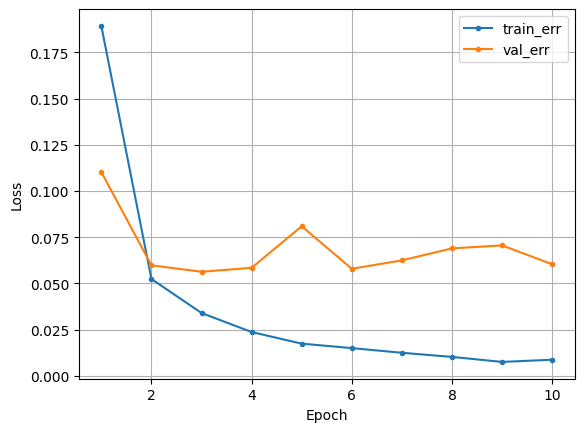

              precision    recall  f1-score   support

           0     1.0000    0.9885    0.9942       520
           1     0.9965    1.0000    0.9982       564
           2     0.9980    0.9960    0.9970       502
           3     0.9961    1.0000    0.9980       510
           4     0.9938    0.9979    0.9959       482
           5     0.9908    0.9931    0.9920       436
           6     0.9960    0.9980    0.9970       496
           7     0.9980    0.9884    0.9932       516
           8     0.9938    0.9959    0.9949       485
           9     0.9878    0.9939    0.9908       489

    accuracy                         0.9952      5000
   macro avg     0.9951    0.9952    0.9951      5000
weighted avg     0.9952    0.9952    0.9952      5000



In [16]:
# 학습
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model2, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}")

# 예측
_, pred = evaluate(x_test, y_test, model2, loss_fn, device)
pred = nn.functional.softmax(pred, dim=1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# learning curve
dl_learning_curve(tr_loss_list, val_loss_list)

# 평가
print(classification_report(y_test.numpy(), pred, digits = 4))

In [19]:
# 참고. layer별 output size 출력
class CNN_model2(nn.Module):
    def __init__(self):
        super(CNN_model2, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
    def forward(self, x):
        print(f"- input size: {x.shape}")
        x = self.relu(self.conv1(x))
        print(f"- Conv1 output size: {x.shape}")
        x = self.pool1(x)
        print(f"- MaxPool1 output size: {x.shape}")
        x = self.relu(self.conv2(x))
        print(f"- Conv2 output size: {x.shape}")
        x = self.pool2(x)
        print(f"- MaxPool2 output size: {x.shape}")
        return x

In [20]:
model2 = CNN_model2()
input = x_test[0:10]
output = model2(input)

- input size: torch.Size([10, 1, 28, 28])
- Conv1 output size: torch.Size([10, 32, 28, 28])
- MaxPool1 output size: torch.Size([10, 32, 14, 14])
- Conv2 output size: torch.Size([10, 64, 14, 14])
- MaxPool2 output size: torch.Size([10, 64, 7, 7])
